In [1]:
import numpy as np
import math
from skimage import color
from skimage import io
import matplotlib.pyplot as plt
import cv2
from scipy import ndimage


In [2]:
# efficient median

def effMedian(image, old_hist, old_median, mask_size, row, col, ltm):
    # data is the window around the current pixel with given mask size
    data = image[row-math.floor(mask_size/2):row+math.floor(mask_size/2), col+math.floor(mask_size/2)]

    # old_data is the window around the previous pixel with given mask size
    old_data = image[row-math.floor(mask_size/2):row+math.floor(mask_size/2), col-math.floor(mask_size/2)-1]
    old_data = old_data.transpose()

    # reshape old_data so that it is a vector rather than a matrix
    old_data = old_data.reshape(1, [], order='F').copy()

    # define threshold value and other parameters
    th = math.floor((mask_size^2)/2)
    n = len(data)
    hist = old_hist

    # --- UPDATE HISTOGRAM ---------------------------------
    
    # delete the leftmost column of the previous window 
    for i in range(n):
        # check if value is less than the median
        if old_data[i] < old_median:
            # increment counter
            ltm = ltm - 1

        # Remove data from the number it represents in the histogram. Note histogram
        # will go from 1-256 but greyscale is 0-255 so add 1 to position.
        hist[old_data[i]+1] = hist[old_data[i]+1] - 1

    # add the rightmost column of the current window
    for i in range(n):
        # check if value is less than the median
        if data[i] < old_median:
            # increment counter
            ltm = ltm + 1
            
        # Add data to the number it represents in the histogram.
        hist[data[i]+1] = hist[data[i]+1] + 1

    # copy variables
    median_out = old_median
    hist_out = hist

    # --- FIND THE MEDIAN ------------------------------------------

    # median of current window is smaller than the one in the previous window
    if ltm > th:
        # Repeat while the above statement is true
        while ltm > th:
            # decrement median
            median_out = median_out - 1
        
            # decrement counter based on value in histogram for new median
            ltm = ltm - hist[median_out+1]
        
    # median of current window is greater than the one in the previous window
    else:
        # Repeat while the above statement is true
        while ltm + hist[median_out+1] <= th:
            # increment counter based on value in histogram for new median
            ltm = ltm + hist(median_out+1)

            # increment median
            median_out = median_out + 1

    return median_out, hist_out, ltm

In [3]:
# histogram median

def histMedian(image, mask_size, row, col):
    # data is the window around the current pixel with given mask size
    data = image[row-math.floor(mask_size/2):row+math.floor(mask_size/2), col-math.floor(mask_size/2):col+math.floor(mask_size/2)]

    # reshape data so that it is a vector rather than a matrix
    data = data.reshape(1, [], order='F').copy()

    # define threshold value and other parameters
    n = len(data)
    hist = np.zeros(1,256)

    # Iterate through the flattened window
    for i in range(n):
        # Add data to the number it represents in the histogram. Note histogram
        # will go from 1-256 but greyscale is 0-255 so add 1 to position.
        hist[data[i]+1] = hist[data[i]+1] + 1; 

    # copy variable
    hist_out = hist
    k = 1

    # Iterate through the histogram
    for j in range(256):
        # Check when there a pixel has been added to the histogram
        while hist[j]>0:
            # set current pixel to the number in the histogram
            sorted_data[k] = j-1

            # decrement histogram
            hist[j] = hist[j] - 1

            # increment counter
            k = k + 1

    # Median is the centre value of ordered array
    median_out = sorted_data(math.ceil(len(sorted_data)/2))

    # Calculate number of pixels less than median, this is not used for a
    # normal histogram search but is used in the efficient version.
    ltm = 0
    # iterate through flattened window
    for i in range(n):
        # check if value is less than the median
        if data[i] < median_out:
            
            # increment counter
            ltm = ltm + 1


(807, 454)


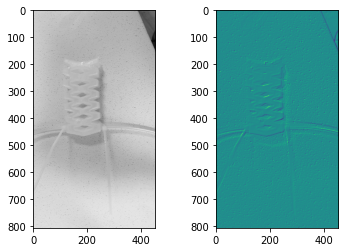

In [4]:
# Display image
# read image as a matrix 
Xo = io.imread('worm_pic.jpg')

# Reduce from rgb to greyscale image (3 dimensions to 2)
Xo = color.rgb2gray(Xo)

# downsample image to reduce computing time - repeat for both dimensions of
# matrix
Xo=Xo[0::5,0::5]
# Xo = imadjust(Xo, [], [], 4) 
print(Xo.shape)

# convolute with sobel kernels
sobelx = cv2.Sobel(Xo,cv2.CV_64F,1,0,ksize=5)  # x
sobely = cv2.Sobel(Xo,cv2.CV_64F,0,1,ksize=5)  # y

# edge = ndimage.sobel(Xo)
edge = sobelx + sobely

fig, (ax1, ax2) = plt.subplots(1, 2)
ax1.imshow(Xo,cmap=plt.cm.gray)
ax2.imshow(edge)


In [5]:
# Efficient 2D median filter

# Create a mask for the median filter and display using a histogram for the sorting method. Results in an identical output as previous median 
# filters but is much more computationally efficient.

# create a mask for the mean filter and display 
print("Efficient 2D Median Filter")

# Define the number of rows and columns in image and the mask size to be
# used.
[n_rows, n_cols] = Xo.shape
mask_size = 9

# Boundary replication by mirroring all pixels within the size of the mask
X = Xo[1:mask_size,:]; Xo; Xo[-1-mask_size:-1,:]; 
X = X[:,1:mask_size], X, X[:,-1-mask_size:-1]; 

# Storage and initialisation of parameters
x_my_eff_median = np.zeros([n_rows, n_cols])
# x_my_eff_median=uint8(x_my_eff_median)
m = 1
n = 1
ltm = 4

# Iterates through each row and column in the image
for i in np.arange(mask_size-1,n_rows+(mask_size-2), 1, dtype=int):
    for j in np.arange(mask_size-1,n_cols+(mask_size-2), 1, dtype=int):
        # Calculates the median of the current window using the normal histogram method until the mask size is exceeded
        if j <= mask_size:
            [median_out, hist, ltm] = histMedian(X, mask_size, i, j)

        # Calculates the median of the current window using the efficient
        # method for all other points in the image
        else:
            [median_out, hist, ltm] = effMedian(X, hist, median_out, mask_size, i, j, ltm);            
        
        # Replace current pixel value with calculated median
        x_my_eff_median[m,n] = median_out

        # keep a history of the previous median value
        old_median = median_out 
        n = n + 1
    
    m = m + 1
    n = 1

# # Display the output filtered image
# figure, imshow(x_my_eff_median)

# # Display the detection output of filtered image
# figure, edge(x_my_eff_median, "sobel")

# new_edge = edge(x_my_eff_median, "sobel");
# superimpose = imfuse(new_edge, original_edge);
# figure, imshow(superimpose) 

Efficient 2D Median Filter


TypeError: tuple indices must be integers or slices, not tuple